--- 1. ADIM: VERİLERİN RAM DOSTU OKUNMASI ---
Dosyalar başarıyla belleğe alındı.

--- 2. ADIM: TABLOLARI AKILLICA BİRLEŞTİRME (MERGE) ---
Birleştirme Tamamlandı! Ana tablomuzun satır ve sütun sayısı: (1384617, 14)

--- 3. ADIM: GELİŞMİŞ EDA VE VERİ TEMİZLİĞİ ---
Eksik Değer Sayıları:
 Series([], dtype: int64)
-> 'days_since_prior_order' içindeki eksik değerler ilk sipariş sembolü olarak -1 ile dolduruldu.

Verinin Genel İstatistik Özeti:


/tmp/ipykernel_1693/2163590262.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.final_df['days_since_prior_order'].fillna(-1, inplace=True)


                            count          mean            std  min       25%  \
order_id                1384617.0  1.706298e+06  989732.648868  1.0  843370.0   
product_id              1384617.0  2.555624e+04   14121.272449  1.0   13380.0   
add_to_cart_order       1384617.0  8.758044e+00       7.423936  1.0       3.0   
reordered               1384617.0  5.985944e-01       0.490183  0.0       0.0   
user_id                 1384617.0  1.031128e+05   59487.147887  1.0   51732.0   
order_number            1384617.0  1.709141e+01      16.614037  4.0       6.0   
order_dow               1384617.0  2.701392e+00       2.167646  0.0       1.0   
order_hour_of_day       1384617.0  1.357759e+01       4.238458  0.0      10.0   
days_since_prior_order  1384617.0  1.706613e+01      10.414070  0.0       7.0   
aisle_id                1384617.0  7.130423e+01      38.104094  1.0      31.0   
department_id           1384617.0  9.839777e+00       6.292830  1.0       4.0   

                           

/tmp/ipykernel_1693/2163590262.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_dow', data=self.final_df, palette='viridis')
/tmp/ipykernel_1693/2163590262.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_hour_of_day', data=self.final_df, palette='magma')


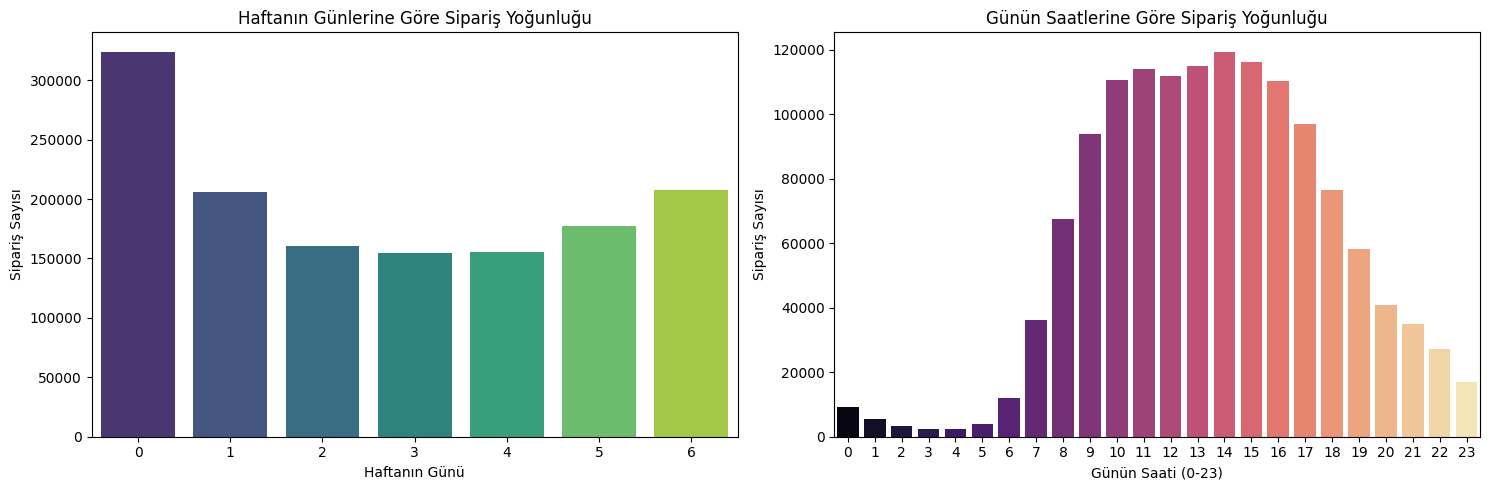

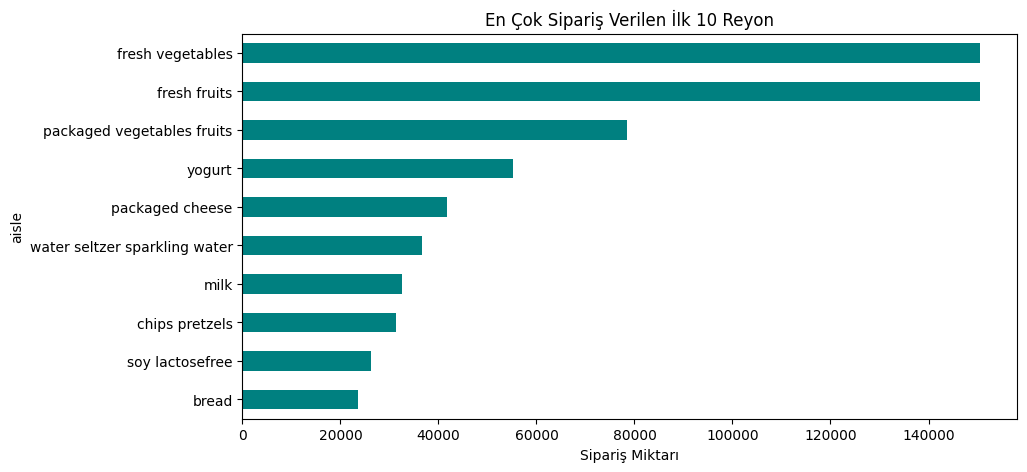

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

class InstacartModelPipeline:
    def __init__(self):
        self.dtypes = {
            'order_id': np.int32,
            'product_id': np.int32,
            'add_to_cart_order': np.int16,
            'reordered': np.int8,
            'user_id': np.int32,
            'order_number': np.int16,
            'order_dow': np.int8,
            'order_hour_of_day': np.int8,
            'days_since_prior_order': np.float32,
            'aisle_id': np.int16,
            'department_id': np.int16
        }
        # Veri çerçevelerini depolamak için nitelikler
        self.aisles = None
        self.departments = None
        self.products = None
        self.orders = None
        self.order_products_train = None
        self.df_prod_details = None
        self.df_train = None
        self.final_df = None

        # Bu sınıf sadece ilk aşama için, modelleme adımları ayrı bir sınıfta olacak
        self.model_df = None
        self.model = None
        self.X_train, self.X_test = None, None
        self.y_train, self.y_test = None, None

    def _load_raw_data(self):
        print("--- 1. ADIM: VERİLERİN RAM DOSTU OKUNMASI ---")
        self.aisles = pd.read_csv('/content/aisles.csv', dtype=self.dtypes)
        self.departments = pd.read_csv('/content/departments.csv', dtype=self.dtypes)
        self.products = pd.read_csv('/content/products.csv', dtype=self.dtypes)
        self.orders = pd.read_csv('/content/orders.csv', dtype=self.dtypes)
        self.order_products_train = pd.read_csv('/content/order_products__train.csv', dtype=self.dtypes)
        print("Dosyalar başarıyla belleğe alındı.")

    def _merge_data(self):
        print("\n--- 2. ADIM: TABLOLARI AKILLICA BİRLEŞTİRME (MERGE) ---")
        # Adım A: Ürünler, Reyonlar (Aisles) ve Departmanları birleştirelim
        self.df_prod_details = pd.merge(self.products, self.aisles, on='aisle_id', how='left')
        self.df_prod_details = pd.merge(self.df_prod_details, self.departments, on='department_id', how='left')

        # Adım B: Sipariş detayları ile Sipariş bilgilerini birleştirelim (Sadece 'train' kümesi)
        orders_train_meta = self.orders[self.orders['eval_set'] == 'train']
        self.df_train = pd.merge(self.order_products_train, orders_train_meta, on='order_id', how='inner')

        # Adım C: Son olarak ürün detaylarını bu ana tabloya ekleyelim
        self.final_df = pd.merge(self.df_train, self.df_prod_details, on='product_id', how='left')
        self.final_df.drop('eval_set', axis=1, inplace=True)
        print(f"Birleştirme Tamamlandı! Ana tablomuzun satır ve sütun sayısı: {self.final_df.shape}")

    def _eda_and_clean(self):
        print("\n--- 3. ADIM: GELİŞMİŞ EDA VE VERİ TEMİZLİĞİ ---")
        # Eksik Değer Kontrolü
        missing_values = self.final_df.isnull().sum()
        print("Eksik Değer Sayıları:\n", missing_values[missing_values > 0])

        # 'days_since_prior_order' sütunundaki eksik değerleri doldurma
        self.final_df['days_since_prior_order'].fillna(-1, inplace=True)
        print("-> 'days_since_prior_order' içindeki eksik değerler ilk sipariş sembolü olarak -1 ile dolduruldu.")

        # Temel İstatistiksel Özet
        print("\nVerinin Genel İstatistik Özeti:")
        print(self.final_df.describe().T)

    def _visualize_data(self):
        print("\n--- 4. ADIM: İLK GÖRSELLEŞTİRMELER (VERİYİ ANLAMA) ---")
        plt.figure(figsize=(15, 5))

        # Grafik 1: Siparişlerin haftanın günlerine göre dağılımı
        plt.subplot(1, 2, 1)
        sns.countplot(x='order_dow', data=self.final_df, palette='viridis')
        plt.title('Haftanın Günlerine Göre Sipariş Yoğunluğu')
        plt.xlabel('Haftanın Günü')
        plt.ylabel('Sipariş Sayısı')

        # Grafik 2: Siparişlerin günün saatlerine göre dağılımı
        plt.subplot(1, 2, 2)
        sns.countplot(x='order_hour_of_day', data=self.final_df, palette='magma')
        plt.title('Günün Saatlerine Göre Sipariş Yoğunluğu')
        plt.xlabel('Günün Saati (0-23)')
        plt.ylabel('Sipariş Sayısı')

        plt.tight_layout()
        plt.show()

        # En çok sipariş edilen ilk 10 reyonu görelim
        plt.figure(figsize=(10, 5))
        self.final_df['aisle'].value_counts().head(10).plot(kind='barh', color='teal').invert_yaxis()
        plt.title('En Çok Sipariş Verilen İlk 10 Reyon')
        plt.xlabel('Sipariş Miktarı')
        plt.show()

    def run_pipeline(self):
        self._load_raw_data()
        self._merge_data()
        self._eda_and_clean()
        self._visualize_data()
        return self.final_df

# Create an instance of the pipeline and run it
pipeline = InstacartModelPipeline()
final_df = pipeline.run_pipeline()



--- 5. ADIM: ÖZELLİK MÜHENDİSLİĞİ ---
Özellik mühendisliği tamamlandı. Model veri setinin boyutu: (1384617, 9)

--- 6. ADIM: VERİYİ MODELLEME İÇİN HAZIRLAMA (TRAIN/TEST SPLIT) ---
Veri, eğitim ve test setlerine ayrıldı.
Eğitim seti boyutu: (1107693, 8), Test seti boyutu: (276924, 8)

--- 7. ADIM: MODEL EĞİTİMİ (LightGBM) ---
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 663059, number of negative: 444634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10605
[LightGBM] [Info] Number of data points in the train set: 1107693, number of used features: 8
[LightGBM] [I

<Figure size 1000x600 with 0 Axes>

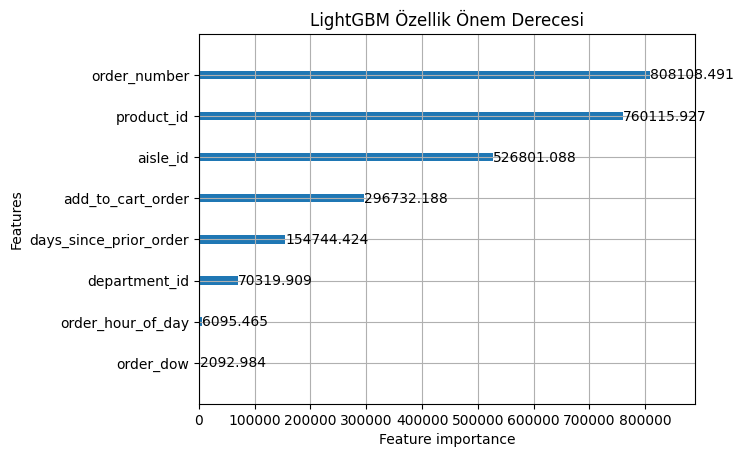

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

class InstacartModelingSteps:
    def __init__(self, final_df):
        self.base_df = final_df.copy() # Use a copy to avoid modifying the original final_df
        self.model_df = None
        self.X = None
        self.y = None
        self.X_train, self.X_test = None, None
        self.y_train, self.y_test = None, None
        self.model = None

    def _feature_engineering(self):
        print("\n--- 5. ADIM: ÖZELLİK MÜHENDİSLİĞİ ---")
        self.model_df = self.base_df.copy()

        # Kategorik özellikleri LightGBM'in anlayacağı şekilde ayarlayalım
        categorical_features = ['product_id', 'aisle_id', 'department_id', 'order_dow', 'order_hour_of_day']
        for col in categorical_features:
            if col in self.model_df.columns:
                self.model_df[col] = self.model_df[col].astype('category')

        # Model için gereksiz sütunları düşürelim
        columns_to_drop_for_model = ['order_id', 'user_id', 'product_name', 'aisle', 'department']
        self.model_df.drop(columns=[col for col in columns_to_drop_for_model if col in self.model_df.columns], inplace=True, errors='ignore')

        print(f"Özellik mühendisliği tamamlandı. Model veri setinin boyutu: {self.model_df.shape}")

    def _prepare_for_modeling(self):
        print("\n--- 6. ADIM: VERİYİ MODELLEME İÇİN HAZIRLAMA (TRAIN/TEST SPLIT) ---")
        if self.model_df is None:
            self._feature_engineering()

        # Hedef değişken ve özellikler
        self.y = self.model_df['reordered']
        self.X = self.model_df.drop('reordered', axis=1)

        # Veriyi eğitim ve test setlerine ayırma
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        print(f"Veri, eğitim ve test setlerine ayrıldı.")
        print(f"Eğitim seti boyutu: {self.X_train.shape}, Test seti boyutu: {self.X_test.shape}")

    def _train_model(self):
        print("\n--- 7. ADIM: MODEL EĞİTİMİ (LightGBM) ---")
        if self.X_train is None or self.y_train is None:
            self._prepare_for_modeling()

        # LightGBM sınıflandırıcısı tanımlama
        self.model = lgb.LGBMClassifier(random_state=42, n_estimators=500, learning_rate=0.05, num_leaves=31)

        # Kategorik özellikleri modelde belirtmek için
        categorical_features_in_X = [col for col in self.X.columns if self.X[col].dtype.name == 'category']

        # Modeli eğitme
        self.model.fit(self.X_train, self.y_train,
                       categorical_feature=categorical_features_in_X,
                       eval_set=[(self.X_test, self.y_test)],
                       eval_metric='logloss',
                       callbacks=[lgb.early_stopping(10, verbose=False)])

        print("Model başarıyla eğitildi.")

    def _evaluate_model(self):
        print("\n--- 8. ADIM: MODEL DEĞERLENDİRME ---")
        if self.model is None:
            self._train_model()

        # Test seti üzerinde tahmin yapalım
        y_pred = self.model.predict(self.X_test)

        # Doğruluk (Accuracy) ve F1 Skoru hesaplayalım
        accuracy = accuracy_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)

        print(f"Model Doğruluğu (Accuracy): {accuracy:.4f}")
        print(f"Model F1 Skoru: {f1:.4f}")

        # Feature Importance (Özellik Önem Derecesi) görselleştirme
        plt.figure(figsize=(10, 6))
        lgb.plot_importance(self.model, max_num_features=10, importance_type='gain', title='LightGBM Özellik Önem Derecesi')
        plt.show()

    def run_modeling_pipeline(self):
        self._feature_engineering()
        self._prepare_for_modeling()
        self._train_model()
        self._evaluate_model()


# Instantiate and run the modeling pipeline
modeling_pipeline = InstacartModelingSteps(final_df)
modeling_pipeline.run_modeling_pipeline()


--- 9. ADIM: DETAYLI MODEL PERFORMANS ANALİZİ ---

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.64      0.53      0.58    111159
           1       0.72      0.80      0.76    165765

    accuracy                           0.69    276924
   macro avg       0.68      0.67      0.67    276924
weighted avg       0.69      0.69      0.69    276924



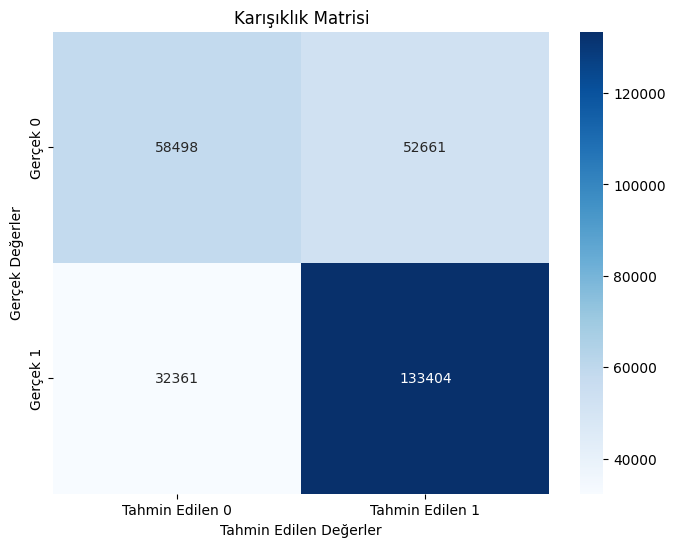

<Figure size 1000x700 with 0 Axes>

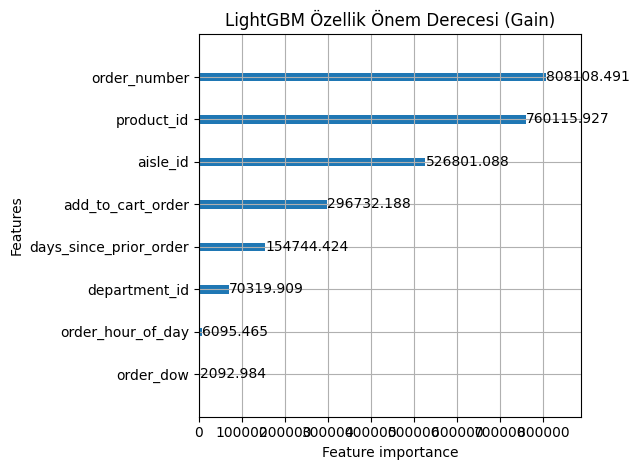

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- 9. ADIM: DETAYLI MODEL PERFORMANS ANALİZİ ---")

# Test seti üzerinde tahminleri alalım
y_pred = modeling_pipeline.model.predict(modeling_pipeline.X_test)

# Sınıflandırma Raporu
print("\nSınıflandırma Raporu:")
print(classification_report(modeling_pipeline.y_test, y_pred))

# Karışıklık Matrisi
cm = confusion_matrix(modeling_pipeline.y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tahmin Edilen 0', 'Tahmin Edilen 1'],
            yticklabels=['Gerçek 0', 'Gerçek 1'])
plt.title('Karışıklık Matrisi')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Özellik Önem Derecesi (Yeniden Gösterim, daha belirgin olması için)
plt.figure(figsize=(10, 7))
lgb.plot_importance(modeling_pipeline.model, max_num_features=15, importance_type='gain', title='LightGBM Özellik Önem Derecesi (Gain)')
plt.tight_layout()
plt.show()

### Model Değerlendirmesi Sonuçları

Yukarıdaki çıktılarda modelinizin performansını daha detaylı görebilirsiniz:

*   **Sınıflandırma Raporu:** Her sınıf (ürünün yeniden sipariş edilip edilmemesi) için precision, recall ve f1-score gibi metrikleri gösterir. `0` sınıfı ürünün yeniden sipariş edilmediğini, `1` sınıfı ise yeniden sipariş edildiğini temsil eder.
    *   **Precision (Kesinlik):** Modelin bir sınıfı doğru tahmin etme oranı (Pozitif tahmin edilenlerden gerçekten pozitif olanlar).
    *   **Recall (Duyarlılık):** Gerçekte pozitif olanları modelin ne kadarının doğru tahmin ettiği (Gerçek pozitiflerden tahmin edilen pozitif olanlar).
    *   **F1-Score:** Precision ve Recall'un harmonik ortalamasıdır ve dengeli bir performans ölçüsüdür.

*   **Karışıklık Matrisi (Confusion Matrix):** Modelin yaptığı doğru ve yanlış sınıflandırmaları görsel olarak sunar.
    *   **`Gerçek 0 / Tahmin Edilen 0` (True Negatives):** Modelin doğru bir şekilde yeniden sipariş edilmeyecek dediği ürün sayısı.
    *   **`Gerçek 1 / Tahmin Edilen 1` (True Positives):** Modelin doğru bir şekilde yeniden sipariş edilecek dediği ürün sayısı.
    *   **`Gerçek 0 / Tahmin Edilen 1` (False Positives):** Modelin yanlış bir şekilde yeniden sipariş edilecek dediği ürün sayısı (Type I hata).
    *   **`Gerçek 1 / Tahmin Edilen 0` (False Negatives):** Modelin yanlış bir şekilde yeniden sipariş edilmeyecek dediği ürün sayısı (Type II hata).

*   **LightGBM Özellik Önem Derecesi:** Model eğitiminde hangi özelliklerin en etkili olduğunu gösterir. `gain` tabanlı önem derecesi, bir özelliğin modelin genel performansına ne kadar katkıda bulunduğunu belirtir. Bu görselleştirme, modelin kararları üzerinde en büyük etkiye sahip olan değişkenleri anlamanıza yardımcı olur.